In [1]:
import sys
!{sys.executable} -m pip install -q pandas matplotlib 2>/dev/null || true

In [2]:
import pandas as pd
df = pd.read_csv("data.csv", low_memory=False)
# `name` is Optional (an unnamed trace track/slice is null): read it as a nullable string so
# .str ops work even when a subset is all-null (a float column has no .str), and NA is NA (not
# the fake string "nan"). str.contains on it always passes na=False -> a clean boolean mask.
df["name"] = df["name"].astype("string")
ARMS = list(dict.fromkeys(df["dockerfile"].dropna()))          # run order; raw values (docker/Dockerfile.baseline)
def _label(dockerfile):                                        # docker/Dockerfile.baseline -> baseline (display only)
    base = dockerfile.rsplit("/", 1)[-1]                       # drop the docker/ dir
    stem = base[len("Dockerfile."):] if base.startswith("Dockerfile.") else base
    return stem[:-len(".Dockerfile")] if stem.endswith(".Dockerfile") else stem
ARM_LABEL = {a: _label(a) for a in ARMS}
PALETTE = ["#2c7fb8", "#d95f0e", "#31a354", "#756bb1", "#e6550d", "#636363"]
COLORS = {a: PALETTE[i % len(PALETTE)] for i, a in enumerate(ARMS)}

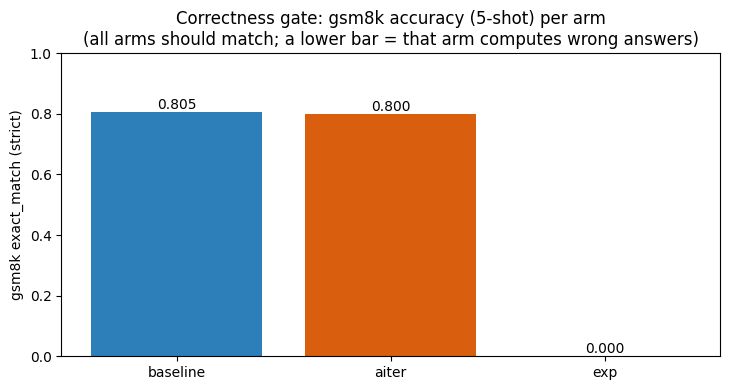


=== baseline: 345/400 correct — examples ===
  [MISS] Q: In the city of Soda, there are exactly 23786 inhabitants. They include 8417 men and 9092 women. The rest of the population is made up of children. How many kids...
         got: 8277
  [MISS] Q: Mandy owes Benedict $100. They agreed to have monthly interest of 2%. If Mandy was able to pay it after 3 months, how much should she give to Benedict?
         got: 106.12
  [MISS] Q: John plans to sell all his toys and use the money to buy video games. He has 13 lego sets and he sells them for $15 each. He ends up buying 8 video games for $2...
         got: 11

=== aiter: 351/400 correct — examples ===
  [MISS] Q: Mandy owes Benedict $100. They agreed to have monthly interest of 2%. If Mandy was able to pay it after 3 months, how much should she give to Benedict?
         got: 106.12
  [MISS] Q: Terry eats 2 yogurts a day.  They are currently on sale at 4 yogurts for $5.00.  How much does he spend on yogurt over 30 days?
         got:

In [3]:
# Correctness gate - gsm8k accuracy (5-shot, strict-match exact_match) one bar per arm,
# from the eval arms (script ./eval.sh, preprocessor parse_eval). Read it FIRST: perf only
# matters if the arm is still correct. All arms should match; a regressed arm scores lower.
import matplotlib.pyplot as plt

ev = df[(df["preprocessor"] == "parse_eval") & (df["cat"] == "gsm8k") &
        (df["variable"] == "exact_match_strict")]
acc = ev.groupby("dockerfile")["value"].first()
if len(acc):
    fig, ax = plt.subplots(figsize=(1.8 * len(ARMS) + 2, 4))
    bars = ax.bar([ARM_LABEL[a] for a in ARMS], [acc.get(a, float("nan")) for a in ARMS],
                  color=[COLORS[a] for a in ARMS])
    ax.bar_label(bars, fmt="%.3f")
    ax.set_ylabel("gsm8k exact_match (strict)")
    ax.set_ylim(0, 1)
    ax.set_title("Correctness gate: gsm8k accuracy (5-shot) per arm\n(all arms should match; a lower bar = that arm computes wrong answers)")
    plt.tight_layout()
    plt.show()
else:
    print("no eval arms in this run (no parse_eval / gsm8k rows) — correctness gate skipped")

# A few actual samples per arm (the grain="eval_sample" rows: name=question, value=correct,
# text=model output) so a LOW-scoring arm's output can be EYEBALLED: garbage vs empty vs a
# plausible-but-wrong answer. Wrong ones first (that's what you want to see); clip the CoT.
S = df[(df["preprocessor"] == "parse_eval") & (df["grain"] == "eval_sample")]
if len(S):
    def _clip(x, n):
        x = "" if pd.isna(x) else str(x).replace("\n", " ")
        return x if len(x) <= n else x[:n] + "..."
    for arm in ARMS:
        sub = S[S["dockerfile"] == arm]
        if not len(sub):
            continue
        sub = sub.sort_values("value")            # correct=value; wrong (0) first
        print(f"\n=== {ARM_LABEL[arm]}: {int(sub['value'].sum())}/{len(sub)} correct — examples ===")
        for _, r in sub.head(3).iterrows():
            print(f"  [{'OK ' if r['value'] else 'MISS'}] Q: {_clip(r['name'], 160)}")
            print(f"         got: {_clip(r['text'], 240)}")

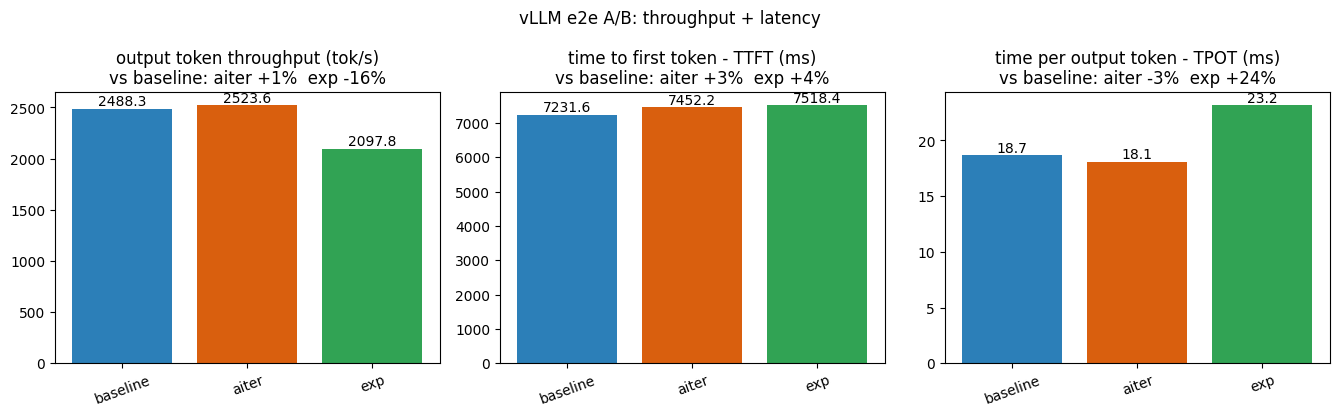

In [4]:
# vLLM e2e A/B - one bar per arm, from the unprofiled bench arms. The three numbers
# that summarize serving: generation rate + the two latency components. Deltas are vs the
# FIRST arm (the baseline reference; ARMS is in run order).
import matplotlib.pyplot as plt

e2e = df[(df["preprocessor"] == "parse_vllm") & (df["script"] == "./scripts/bench.sh")]

# One (variable, statistic, unit) triple -> value per arm. statistic is NaN for the single-
# value throughput; "mean" for the distributional latencies.
def ab(variable, stat, unit):
    m = e2e[(e2e["variable"] == variable) & (e2e["unit"] == unit)]
    m = m[m["statistic"].isna()] if stat is None else m[m["statistic"] == stat]
    return m.groupby("dockerfile")["value"].first()

charts = [
    ("output token throughput (tok/s)", "output_throughput", None,   "tokens_per_s"),  # e2e rate
    ("time to first token - TTFT (ms)", "ttft",              "mean", "ms"),             # prefill latency
    ("time per output token - TPOT (ms)", "tpot",            "mean", "ms"),             # decode latency
]
base = ARMS[0]
fig, axes = plt.subplots(1, len(charts), figsize=(4.5 * len(charts), 4.2))
for ax, (title, variable, stat, unit) in zip(axes, charts):
    g = ab(variable, stat, unit)
    bars = ax.bar([ARM_LABEL[a] for a in ARMS], [g.get(a, float("nan")) for a in ARMS],
                  color=[COLORS[a] for a in ARMS])
    ax.bar_label(bars, fmt="%.1f")
    b = g.get(base)
    deltas = "  ".join(f"{ARM_LABEL[a]} {100 * (g[a] - b) / b:+.0f}%" for a in ARMS[1:] if a in g.index and b)
    ax.set_title(f"{title}\nvs {ARM_LABEL[base]}: {deltas}" if deltas else title)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("vLLM e2e A/B: throughput + latency")
plt.tight_layout()
plt.show()

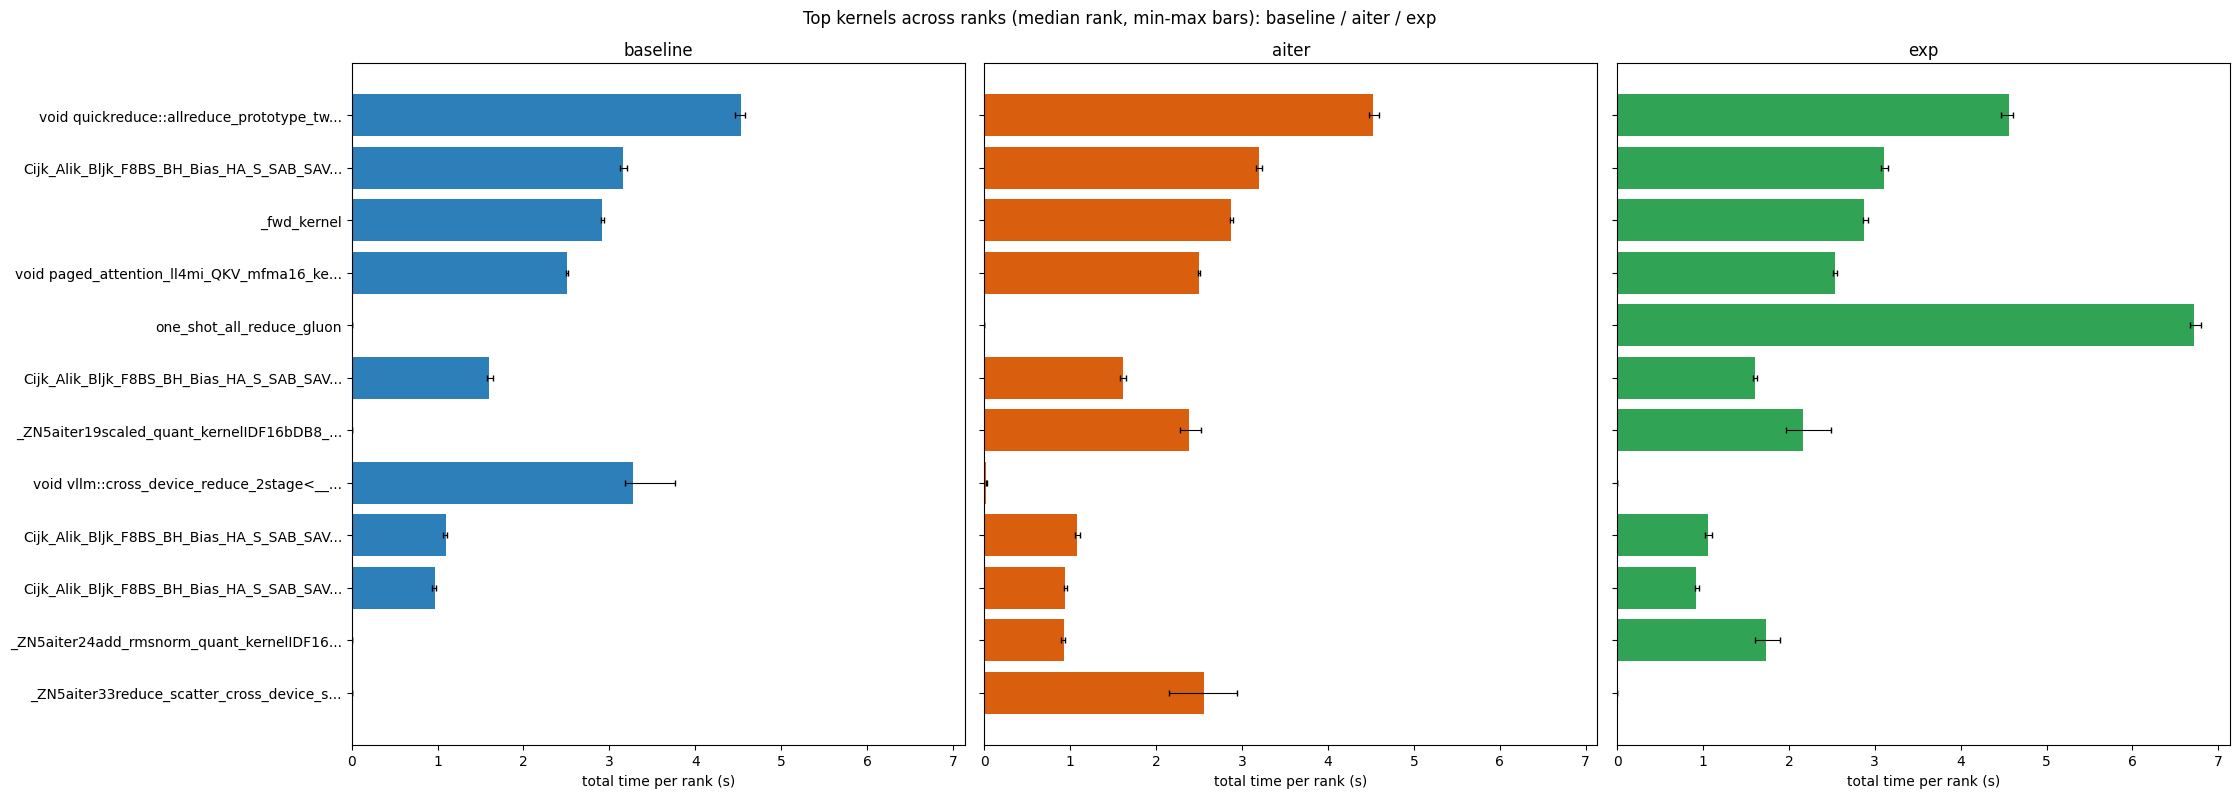

In [5]:
# Across ranks: top kernels by total time, one panel PER ARM, all sharing the same x and y
# axes (same kernel set/order, same scale) so they compare directly. Bar = median across the
# 8 ranks, whiskers = min-max. Dumb - group kernel slices by name, no buckets, real names
# (clipped). Zero bar = kernel absent in that arm.
import matplotlib.pyplot as plt, numpy as np

NAME_LIMIT = 40
def clip(name):
    return name if len(name) <= NAME_LIMIT else name[:NAME_LIMIT] + "..."

k = df[(df["preprocessor"] == "parse_trace") & (df["grain"] == "track_slice") &
       (df["variable"] == "self_time") & (df["cat"] == "kernel")]
# total seconds per (arm, rank, kernel)
per = (k.groupby(["dockerfile", "rank", "name"])["value"].sum() / 1e6).reset_index()

TOPN = 12
top_names = per.groupby("name")["value"].sum().sort_values(ascending=False).head(TOPN).index.tolist()

def stats(name, arm):
    v = per[(per["name"] == name) & (per["dockerfile"] == arm)]["value"]
    return (v.median(), v.min(), v.max()) if len(v) else (0.0, 0.0, 0.0)

y = np.arange(len(top_names))
fig, axes = plt.subplots(1, len(ARMS), figsize=(7.5 * len(ARMS), 0.55 * len(top_names) + 1.5),
                         sharex=True, sharey=True, squeeze=False)
for ax, arm in zip(axes[0], ARMS):
    med, lo, hi = [], [], []
    for nm in top_names:
        m, mn, mx = stats(nm, arm)
        med.append(m); lo.append(m - mn); hi.append(mx - m)
    ax.barh(y, med, color=COLORS[arm], xerr=[lo, hi],
            error_kw=dict(ecolor="black", lw=0.8, capsize=2))
    ax.set_title(ARM_LABEL[arm])
    ax.set_xlabel("total time per rank (s)")
axes[0][0].set_yticks(y)
axes[0][0].set_yticklabels([clip(n) for n in top_names])
axes[0][0].invert_yaxis()   # biggest on top (shared, so all panels follow)
fig.suptitle("Top kernels across ranks (median rank, min-max bars): " + " / ".join(ARM_LABEL[a] for a in ARMS))
plt.tight_layout()
plt.show()

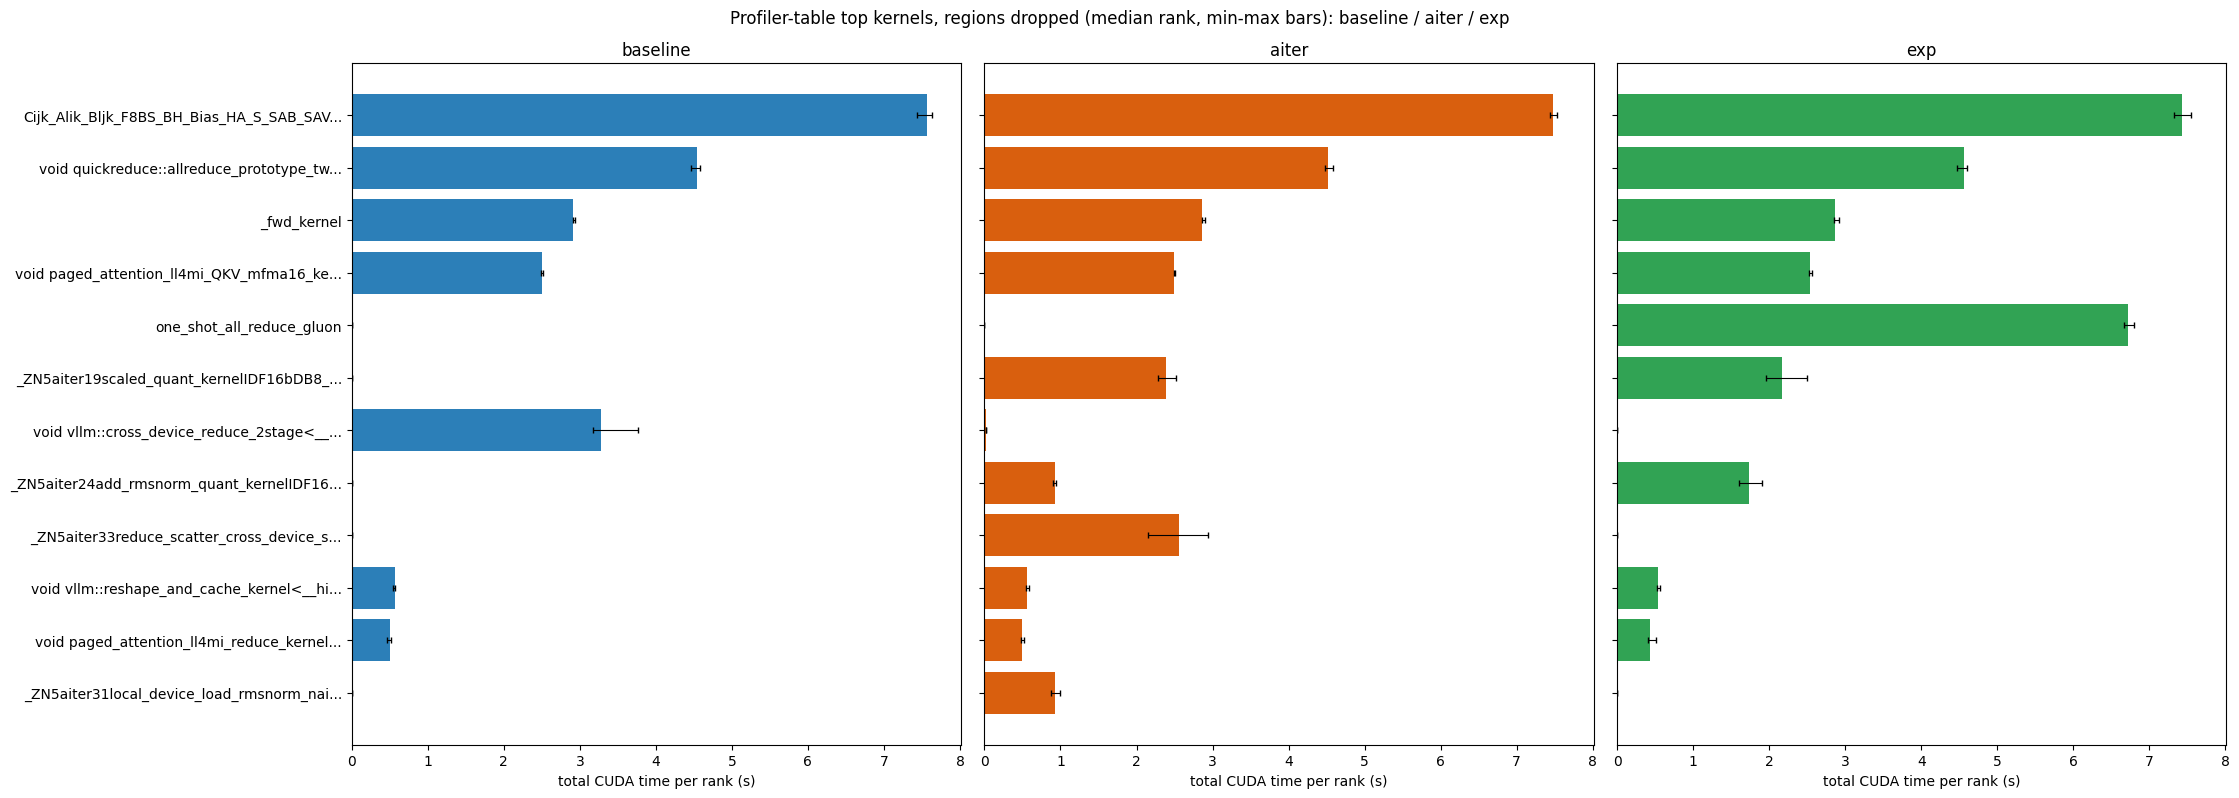

calls  \
arm                        kernel                                                
docker/Dockerfile.baseline void quickreduce::allreduce_prototype_tw...     966   
                           void vllm::cross_device_reduce_2stage<__...  164703   
                           void vllm::cross_device_reduce_1stage<__...     161   
docker/Dockerfile.aiter    void quickreduce::allreduce_prototype_tw...     805   
                           _ZN5aiter33reduce_scatter_cross_device_s...  163680   
                           _ZN5aiter30allreduce_fusion_kernel_1stag...    2560   
                           void vllm::cross_device_reduce_2stage<__...    1023   
                           void vllm::cross_device_reduce_1stage<__...      16   
docker/Dockerfile.exp      one_shot_all_reduce_gluon                    164703   
                           void quickreduce::allreduce_prototype_tw...     966   

                                                                        per-call (us)  \
arm                        kernel                                                       
docker/Dockerfile.baseline void quickreduce::allreduce_prototype_tw...         4697.5   
                           void vllm::cross_device_reduce_2stage<__...           19.9   
                           void vllm::cross_device_reduce_1stage<__...            9.6   
docker/Dockerfile.aiter    void quickreduce::allreduce_prototype_tw...         5617.0   
                           _ZN5aiter33reduce_scatter_cross_device_s...           15.6   
                           _ZN5aiter30allreduce_fusion_kernel_1stag...           12.4   
                           void vllm::cross_device_reduce_2stage<__...           21.7   
                           void vllm::cross_device_reduce_1stage<__...           10.9   
docker/Dockerfile.exp      one_shot_all_reduce_gluon                             40.8   
                           void quickreduce::allreduce_prototype_tw...         4717.0   

                                                                        total (s)  
arm                        kernel                                                  
docker/Dockerfile.baseline void quickreduce::allreduce_prototype_tw...       4.54  
                           void vllm::cross_device_reduce_2stage<__...       3.28  
                           void vllm::cross_device_reduce_1stage<__...       0.00  
docker/Dockerfile.aiter    void quickreduce::allreduce_prototype_tw...       4.52  
                           _ZN5aiter33reduce_scatter_cross_device_s...       2.56  
                           _ZN5aiter30allreduce_fusion_kernel_1stag...       0.03  
                           void vllm::cross_device_reduce_2stage<__...       0.02  
                           void vllm::cross_device_reduce_1stage<__...       0.00  
docker/Dockerfile.exp      one_shot_all_reduce_gluon                         6.71  
                           void quickreduce::allreduce_prototype_tw...       4.56

dominant all-reduce per-call (us) by arm:
  docker/Dockerfile.baseline void quickreduce::allreduce_prototype_tw...  4697.5 us/call  x966  = 4.54s
  docker/Dockerfile.aiter void quickreduce::allreduce_prototype_tw...  5617.0 us/call  x805  = 4.52s
  docker/Dockerfile.exp one_shot_all_reduce_gluon                     40.8 us/call  x164703  = 6.71s


In [6]:
# Cross-check from the PyTorch profiler summary tables (parse_profile), not the traces.
# DEVICE KERNELS ONLY: the table also lists host ops and cudagraph region markers that
# DOUBLE-COUNT the leaf kernels' CUDA time (a host op's CUDA total includes its child kernel
# — that's why QuickReduce appeared twice). A device kernel has Self CPU == 0 (the `self_cpu`
# variable); host ops have Self CPU > 0. Regions (execute_context_*) are Self CPU 0 too, so
# drop them by name. Time by `self_cuda` (device time). Same two-panel median/min-max view.
import matplotlib.pyplot as plt, numpy as np

LIMIT = 40
def clip(name):
    return name if len(name) <= LIMIT else name[:LIMIT] + "..."

prof = df[df["preprocessor"] == "parse_profile"]
hostish = set(prof[(prof["variable"] == "self_cpu") & (prof["value"] > 0)]["name"].dropna())  # host ops (Self CPU > 0)
def device_only(sub):   # leaf device kernels: not a host op, not a cudagraph region marker
    return sub[(~sub["name"].isin(hostish)) &
               (~sub["name"].str.contains("execute_context", na=False))]   # name is "string" dtype (load cell)

pr = device_only(prof[prof["variable"] == "self_cuda"])
perp = (pr.groupby(["dockerfile", "rank", "name"])["value"].sum() / 1e6).reset_index()

TOPN = 12
top_p = perp.groupby("name")["value"].sum().sort_values(ascending=False).head(TOPN).index.tolist()

def statp(name, arm):
    v = perp[(perp["name"] == name) & (perp["dockerfile"] == arm)]["value"]
    return (v.median(), v.min(), v.max()) if len(v) else (0.0, 0.0, 0.0)

yy = np.arange(len(top_p))
fig, axes = plt.subplots(1, len(ARMS), figsize=(7.5 * len(ARMS), 0.55 * len(top_p) + 1.5),
                         sharex=True, sharey=True, squeeze=False)
for ax, arm in zip(axes[0], ARMS):
    med, lo, hi = [], [], []
    for nm in top_p:
        m, mn, mx = statp(nm, arm)
        med.append(m); lo.append(m - mn); hi.append(mx - m)
    ax.barh(yy, med, color=COLORS[arm], xerr=[lo, hi],
            error_kw=dict(ecolor="black", lw=0.8, capsize=2))
    ax.set_title(ARM_LABEL[arm])
    ax.set_xlabel("total CUDA time per rank (s)")
axes[0][0].set_yticks(yy)
axes[0][0].set_yticklabels([clip(n) for n in top_p])
axes[0][0].invert_yaxis()
fig.suptitle("Profiler-table top kernels, regions dropped (median rank, min-max bars): " + " / ".join(ARM_LABEL[a] for a in ARMS))
plt.tight_layout()
plt.show()

# All-reduce kernels PER ARM: calls vs per-call vs total (same profiler table). Calls are
# identical across ranks, so the median IS the per-rank value; per-call/total vary ~1%.
# Arm-agnostic: for each arm, surface whatever all-reduce kernel(s) it actually ran (no
# hardcoded arm->kernel map), so the collective swap shows itself - the finding is that the
# arms run ~equal calls, so the per-call gap IS the total gap (slower PER CALL).
def kstat(sub):
    calls = sub[sub["variable"] == "calls"].groupby("rank")["value"].first().median()
    per_call = sub[sub["variable"] == "cuda_time_avg"].groupby("rank")["value"].first().median()
    total = sub[sub["variable"] == "self_cuda"].groupby("rank")["value"].first().median()
    return calls, per_call, total

ALLREDUCE = "all_reduce|allreduce|cross_device|one_shot|quickreduce"
# device kernels only (drops the host dispatch op that wraps the kernel, e.g.
# _C_custom_ar::qr_all_reduce, so an all-reduce isn't counted twice). na=False keeps a clean mask.
ar = device_only(prof[prof["name"].str.contains(ALLREDUCE, case=False, regex=True, na=False)])
recs = []
for arm in ARMS:
    for name in ar[ar["dockerfile"] == arm]["name"].unique():
        calls, per_call, total = kstat(ar[(ar["dockerfile"] == arm) & (ar["name"] == name)])
        # skip a kernel missing any of its three facts (NaN median = no such row) - int(NaN) raises
        if any(v != v for v in (calls, per_call, total)):
            continue
        recs.append({"arm": arm, "kernel": clip(name), "calls": int(calls),
                     "per-call (us)": round(per_call, 1), "total (s)": round(total / 1e6, 2)})
if recs:
    tbl = pd.DataFrame(recs).set_index(["arm", "kernel"])
    display(tbl)
    # Each arm's DOMINANT all-reduce (most total time) — the per-call comparison across arms.
    dom = tbl.reset_index().sort_values("total (s)", ascending=False).groupby("arm", sort=False).first()
    print("dominant all-reduce per-call (us) by arm:")
    for arm in ARMS:
        if arm in dom.index:
            r = dom.loc[arm]
            print(f"  {arm:10s} {r['kernel']:42s} {r['per-call (us)']:7.1f} us/call  x{int(r['calls'])}  = {r['total (s)']}s")

## Summary

1. Correctness (fig 1): exp is wrong, not just slow. gsm8k exact_match is 0.000 for exp, vs 0.805 baseline and 0.800 aiter. aiter tracks baseline, which isolates the break to the gluon change.
2. e2e (fig 2), deltas vs baseline: exp regresses while aiter matches baseline. Output throughput: exp -15.7%, aiter +1.4%. TPOT: exp +24.2%, aiter -3.1%. TTFT: exp +4.0%, aiter +3.0%. Duration: exp +18.6%, aiter -1.4%. TPOT is hit hardest because the all-reduce is on the decode path, one per output token.
3. all-reduce (figs 3 and 4): the regression is in the decode all-reduce, the one that runs per output token (about 165k calls per rank). baseline runs cross_device_reduce_2stage there at 3.28 s/rank; exp runs one_shot_all_reduce_gluon at 6.71 s/rank, about 2x slower, which accounts for most of the e2e gap. The large-message all-reduce used in prefill (QuickReduce) is a separate kernel and costs about 4.5 s/rank on all three arms, so it is not part of the difference. aiter is not a like-for-like swap: it fuses the decode all-reduce with RMSNorm (reduce_scatter_cross_device_store at 2.56 s/rank paired with local_device_load_rmsnorm at 0.93 s/rank, same call count), so its collective is not directly comparable to the standalone ones.